<a href="https://colab.research.google.com/github/Andavarapu-Snehal-05/Deep-Learning-/blob/main/XOR_Gate(Hardcoded).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

XOR GATE - TWO LAYER PERCEPTRON
Hidden layer weights:
[[ 1  1]
 [-1 -1]]
Hidden layer bias: [[-0.5]
 [-1.5]]
Output layer weights:
[[ 1 -2]]
Output Layer Bias: [[0.5]]

PREDICTIONS
[Input: [0 0]] -> Hidden: [0 0] | Pred: 1 | Actual: 0
[Input: [0 1]] -> Hidden: [0 0] | Pred: 1 | Actual: 1
[Input: [1 0]] -> Hidden: [1 0] | Pred: 1 | Actual: 1
[Input: [1 1]] -> Hidden: [0 0] | Pred: 1 | Actual: 0


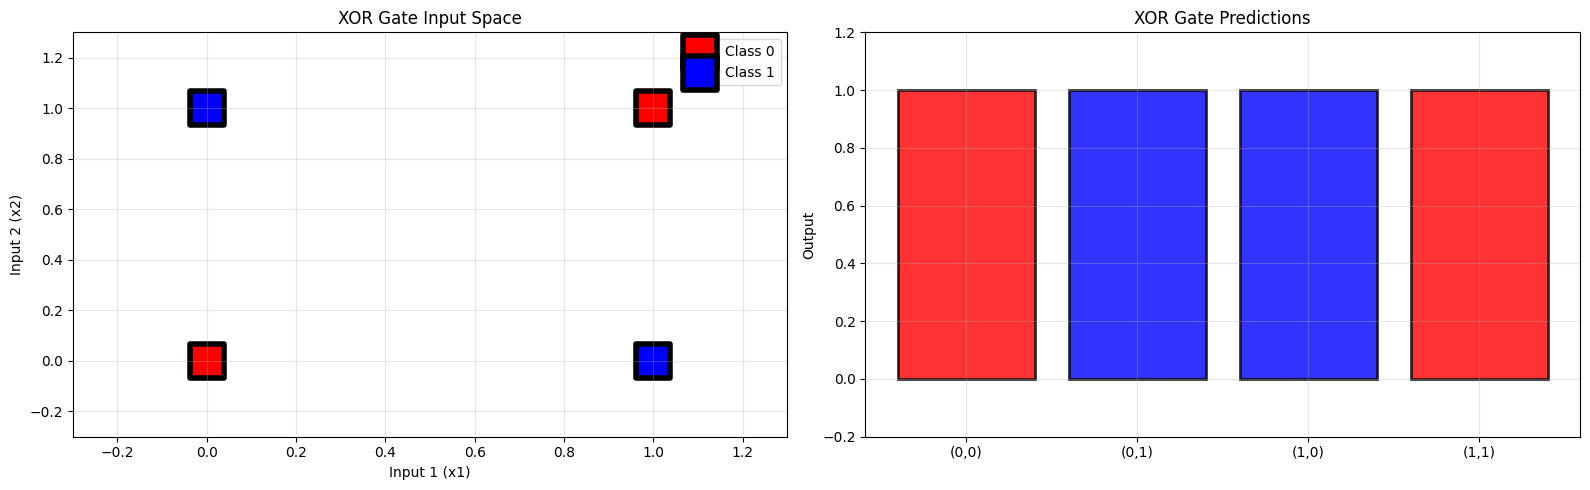


VERIFICATION RESULTS!
[Input: [0 0]] XOR output: 1 (Actual: 0)
[Input: [0 1]] XOR output: 1 (Actual: 1)
[Input: [1 0]] XOR output: 1 (Actual: 1)
[Input: [1 1]] XOR output: 1 (Actual: 0)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

print("XOR GATE - TWO LAYER PERCEPTRON")
print("="*65)

# Weights and biases
w1 = np.array([[1, 1], [-1, -1]])
b1 = np.array([[-0.5], [-1.5]])
w2 = np.array([[1, -2]]) # Assuming two neurons in hidden layer mapped to one output neuron
b2 = np.array([[0.5]])

print("Hidden layer weights:")
print(w1)
print("Hidden layer bias:", b1)
print("Output layer weights:")
print(w2)
print("Output Layer Bias:", b2)

def step_function(x):
    return 1 if x > 0 else 0

def xor_predict(inputs):
    hidden_outputs = []
    predictions = []

    for input_sample in inputs:
        # Hidden layer
        # First neuron
        h1_input = np.dot(input_sample, w1[:, 0]) + b1[0, 0]
        h1 = step_function(h1_input)

        # Second neuron
        h2_input = np.dot(input_sample, w1[:, 1]) + b1[1, 0]
        h2 = step_function(h2_input)

        hidden = np.array([h1, h2])
        hidden_outputs.append(hidden)

        # Output layer
        y_pred_input = np.dot(hidden, w2[0].T) + b2[0, 0]
        y_pred = step_function(y_pred_input)
        predictions.append(y_pred)

    return np.array(hidden_outputs), np.array(predictions).reshape(-1, 1)

# Make predictions
hidden_vals, predictions = xor_predict(x)

print("\nPREDICTIONS")
for i in range(len(x)):
    print(f"[Input: {x[i]}] -> Hidden: {hidden_vals[i]} | Pred: {predictions[i][0]} | Actual: {y[i][0]}")

# Plotting
plt.figure(figsize=(16,5))

plt.subplot(1, 2, 1)

# Plotting XOR gate input space
plt.scatter(x[y.flatten() == 0, 0], x[y.flatten() == 0, 1], s=600, c='red', marker='s', edgecolors='black', linewidth=4, label='Class 0')
plt.scatter(x[y.flatten() == 1, 0], x[y.flatten() == 1, 1], s=600, c='blue', marker='s', edgecolors='black', linewidth=4, label='Class 1')

plt.xlim(-0.3, 1.3)
plt.ylim(-0.3, 1.3)

plt.xlabel('Input 1 (x1)')
plt.ylabel('Input 2 (x2)')
plt.title('XOR Gate Input Space')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)

# Plotting XOR gate predictions
samples = ['(0,0)', '(0,1)', '(1,0)', '(1,1)'] # Labels for bar chart
colors = ['red', 'blue', 'blue', 'red']

plt.bar(samples, predictions.flatten(), color=colors, alpha=0.8, edgecolor="black", linewidth=2)

plt.ylabel('Output')
plt.title('XOR Gate Predictions')
plt.ylim(-0.2, 1.2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVERIFICATION RESULTS!")
for i in range(len(x)):
    print(f"[Input: {x[i]}] XOR output: {predictions[i][0]} (Actual: {y[i][0]})")
